---
title: "Лабораторна робота 8. Побудова дерев ухвалення рішень"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "04.07.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці концепцію алгоритмів кластеризації k-means, DBSCAN та агломеративних засобами мови Python

## Завдання для самостійної роботи 

1. Розглянути наведені вище приклади.
1. Реалізувати алгоритм побудови класифікаційного дерева ухвалення рішень, наведений в роботі, для свого варіанта, обгрунтувавши значення відповідних параметрів.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_8_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

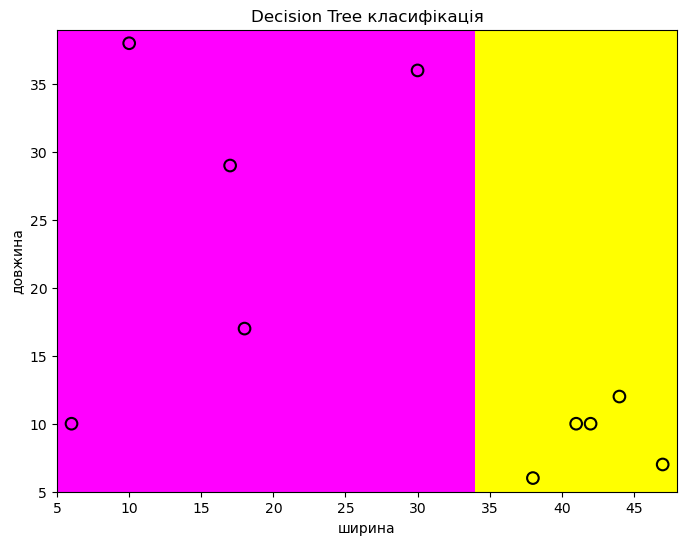

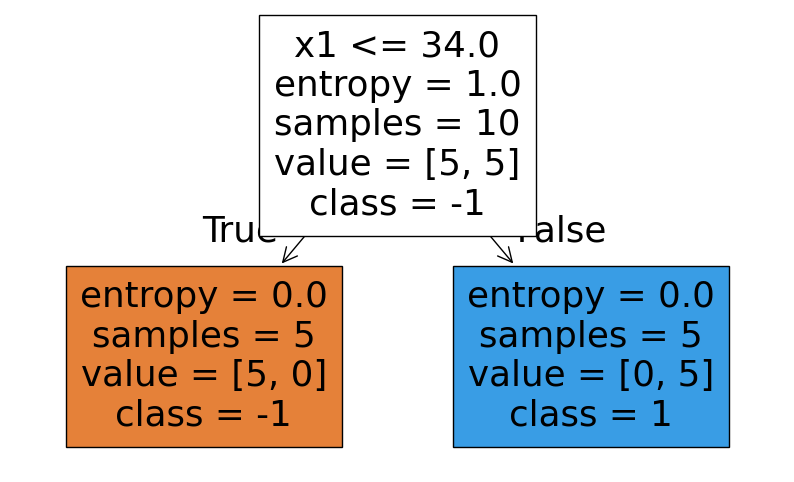

In [2]:
# Дерево ухвалення рішень для задачі класифікації

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Функція для створення сітки
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01),
                       np.arange(y_min, y_max, 0.01))

train_data = np.array([(17, 29), (44, 12), (47, 7), (18, 17), (30, 36), (6, 10), (38, 6), (10, 38), (41, 10), (42, 10)])

# Мітки класів
train_labels = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

# Ініціалізація та навчання дерева
clf_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=5
)

clf_tree.fit(train_data, train_labels)

# Побудова областей класифікації
xx, yy = get_grid(train_data)
predicted = clf_tree.predict(
    np.c_[xx.ravel(), yy.ravel()]
).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.pcolormesh(xx, yy, predicted, cmap='spring', shading='auto')

plt.scatter(
    train_data[:, 0],
    train_data[:, 1],
    c=train_labels,
    s=70,
    cmap='spring',
    edgecolors='black',
    linewidth=1.5
)

plt.xlabel("ширина")
plt.ylabel("довжина")
plt.title("Decision Tree класифікація")
plt.show()

# Візуалізація дерева
plt.figure(figsize=(10,6))
plot_tree(
    clf_tree,
    filled=True,
    feature_names=["x1", "x2"],
    class_names=["-1", "1"]
)
plt.show()